In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_rgb, AsinhStretch
from torchvision.transforms import ToPILImage
import ml_sandbox.dataset as mlds
from importlib import reload
reload(mlds)
get_dataset = mlds.get_dataset


# load galaxy dataset

In [2]:
from galaxy_datasets import gz_candels, gz2


catalog, label_cols = gz2(
        root='.tmp/',
        train=True,
        download=True,
)


In [3]:
catalog.head()

,ra,dec,smooth-or-featured-gz2_smooth,smooth-or-featured-gz2_featured-or-disk,smooth-or-featured-gz2_artifact,disk-edge-on-gz2_yes,disk-edge-on-gz2_no,bar-gz2_yes,bar-gz2_no,has-spiral-arms-gz2_yes,...,something-odd-gz2_semantic,how-rounded-gz2_semantic,bulge-shape-gz2_semantic,spiral-winding-gz2_semantic,spiral-arm-count-gz2_semantic,summary,leaf_prob,label,filename,id_str
0,194.055664,27.823219,37,0,1,0,0,0,0,0,...,something-odd-gz2_no,how-rounded-gz2_round,-,-,-,smooth_round,0.842105,1,587741602572468407.jpg,587741602572468407
1,162.939468,21.025589,40,2,1,0,2,0,2,0,...,something-odd-gz2_no,how-rounded-gz2_in-between,-,-,-,smooth_inbetween,0.697674,0,587742061600833690.jpg,587742061600833690
2,132.911163,25.326416,18,22,1,0,22,4,18,6,...,something-odd-gz2_yes,-,-,-,-,featured_without_bar_or_spiral,0.319290,6,587739115241013526.jpg,587739115241013526
3,216.752670,0.869107,36,3,4,0,3,0,3,0,...,something-odd-gz2_no,how-rounded-gz2_in-between,-,-,-,smooth_inbetween,0.511628,0,587722984440529062.jpg,587722984440529062
4,236.762390,5.435655,22,14,2,13,1,0,1,0,...,something-odd-gz2_no,how-rounded-gz2_cigar,-,-,-,smooth_cigar,0.578947,2,587736547389866123.jpg,587736547389866123


In [4]:
cols = catalog.columns.to_numpy()

# initial testing

In [5]:
from ml_sandbox.dataset import load_image
import numpy as np


In [6]:
import torch

In [7]:
lcols = catalog.columns[catalog.columns.str.startswith('merging-gz2')].to_list()

In [8]:
from galaxy_datasets.pytorch.galaxy_dataset import GalaxyDataset
from torchvision.transforms import ToTensor
import torch
gzdataset = GalaxyDataset(
    catalog,
    label_cols=lcols,  
    # transform=ToTensor(),
    target_transform=lambda x: torch.tensor(x, dtype=torch.float32),
    )

In [9]:
import glob
glob.glob('.tmp/images/*.jpg')

['.tmp/images/UDS_4241.jpg',
 '.tmp/images/GDS_9695.jpg',
 '.tmp/images/UDS_5341.jpg',
 '.tmp/images/GDS_22979.jpg',
 '.tmp/images/COS_19326.jpg',
 '.tmp/images/UDS_2168.jpg',
 '.tmp/images/GDS_1112.jpg',
 '.tmp/images/COS_23915.jpg',
 '.tmp/images/UDS_24821.jpg',
 '.tmp/images/UDS_9377.jpg',
 '.tmp/images/COS_27840.jpg',
 '.tmp/images/UDS_17459.jpg',
 '.tmp/images/COS_21251.jpg',
 '.tmp/images/GDS_6203.jpg',
 '.tmp/images/COS_19303.jpg',
 '.tmp/images/COS_17383.jpg',
 '.tmp/images/GDS_18672.jpg',
 '.tmp/images/COS_16198.jpg',
 '.tmp/images/COS_9042.jpg',
 '.tmp/images/UDS_12824.jpg',
 '.tmp/images/COS_28835.jpg',
 '.tmp/images/GDS_24171.jpg',
 '.tmp/images/COS_11330.jpg',
 '.tmp/images/GDS_16792.jpg',
 '.tmp/images/GDS_6106.jpg',
 '.tmp/images/UDS_11661.jpg',
 '.tmp/images/GDS_24557.jpg',
 '.tmp/images/COS_19685.jpg',
 '.tmp/images/UDS_14754.jpg',
 '.tmp/images/COS_12147.jpg',
 '.tmp/images/GDS_1543.jpg',
 '.tmp/images/GDS_351.jpg',
 '.tmp/images/COS_7895.jpg',
 '.tmp/images/GDS_8798.

In [10]:
catalog.columns

Index(['ra', 'dec', 'smooth-or-featured-gz2_smooth',
       'smooth-or-featured-gz2_featured-or-disk',
       'smooth-or-featured-gz2_artifact', 'disk-edge-on-gz2_yes',
       'disk-edge-on-gz2_no', 'bar-gz2_yes', 'bar-gz2_no',
       'has-spiral-arms-gz2_yes', 'has-spiral-arms-gz2_no',
       'bulge-size-gz2_no', 'bulge-size-gz2_just-noticeable',
       'bulge-size-gz2_obvious', 'bulge-size-gz2_dominant',
       'something-odd-gz2_yes', 'something-odd-gz2_no',
       'how-rounded-gz2_round', 'how-rounded-gz2_in-between',
       'how-rounded-gz2_cigar', 'bulge-shape-gz2_round',
       'bulge-shape-gz2_boxy', 'bulge-shape-gz2_no-bulge',
       'spiral-winding-gz2_tight', 'spiral-winding-gz2_medium',
       'spiral-winding-gz2_loose', 'spiral-arm-count-gz2_1',
       'spiral-arm-count-gz2_2', 'spiral-arm-count-gz2_3',
       'spiral-arm-count-gz2_4', 'spiral-arm-count-gz2_more-than-4',
       'spiral-arm-count-gz2_cant-tell', 'smooth-or-featured-gz2_total-votes',
       'smooth-or-featur

In [11]:
reload(mlds)
get_dataset = mlds.get_dataset
dataset_tr = get_dataset(catalog, label_keys=['disk-edge-on-gz2_yes','disk-edge-on-gz2_no',], size=None, train=True, dir='.tmp/')

In [12]:
reload(mlds)
a = torch.tensor([0.1, 0.1, 0.1])
mlds.assign_label_by_max_vote(a)

tensor(0)

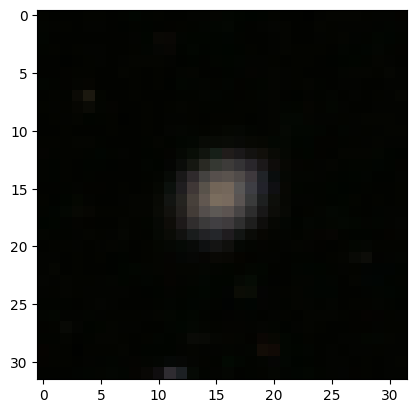

In [13]:
im, lab = dataset_tr[5]
plt.imshow(im.permute(1,2,0))

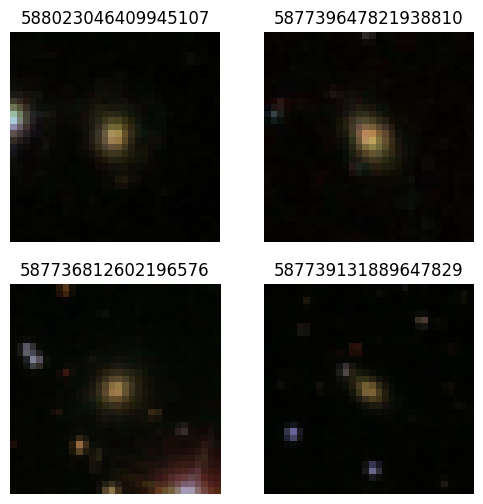

In [14]:
from ml_sandbox.utils import show_sample_images
for i in range(3,4):
    show_sample_images(dataset_tr, num_images=i+1)

# training

In [15]:
from ml_sandbox.models import SimpleCNNClassifier, TransformerClassifier
import ml_sandbox.train_eval as mlte
reload(mlte)
train_torch_model = mlte.train_torch_model
test_torch_model  = mlte.test_torch_model
from ml_sandbox.dataset import get_dataloader
from sklearn.model_selection import train_test_split


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [17]:

label_keys=['disk-edge-on-gz2_yes','disk-edge-on-gz2_no',]
model = TransformerClassifier(num_classes=len(label_keys), input_channels=3)
model=model.to(device)

train_cat, test_cat = train_test_split(catalog, test_size=0.2, random_state=42)

train_dataset = get_dataset(train_cat, label_keys=label_keys, resize = 28,
                            size=train_cat.shape[0] // 5, train=True, dir='.tmp/')
test_dataset = get_dataset(test_cat, label_keys=label_keys, resize = 28,
                           size=test_cat.shape[0] // 5, train=False, dir='.tmp/')

train_loader = get_dataloader(train_dataset, batch_size=8)
test_loader = get_dataloader(test_dataset, batch_size=8)


all_labels = []
for _, y in train_loader:
    all_labels.extend(y.tolist())

#balance classes
class_counts = torch.tensor([all_labels.count(c) for c in range(len(label_keys))], dtype=torch.float)
weights = 1.0 / class_counts
weights = weights / weights.sum() * len(class_counts)  # normalize
weights = weights.to(device)

from torch.nn import CrossEntropyLoss
criterion = CrossEntropyLoss(weight=weights)

from torch.optim import Adam
optimizer = Adam(model.parameters(), lr=1e-3)

In [18]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    print(labels.dim())
    break

torch.Size([8, 3, 28, 28]) torch.Size([8])
1


In [19]:
hist = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

do_torch_training = True
if do_torch_training:
    for i in range(15):
        train_loss, train_acc = train_torch_model(train_loader, model, criterion, optimizer, device=device) 
        test_loss, test_acc = test_torch_model(test_loader, model, criterion, device=device)
        hist['train_loss'].append(train_loss)
        hist['train_acc'].append(train_acc)
        hist['test_loss'].append(test_loss)
        hist['test_acc'].append(test_acc)
        print(f"Epoch: {i+1}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

loss: 0.705711  [    8/26789]
loss: 0.635525  [  808/26789]
loss: 0.808102  [ 1608/26789]
loss: 0.566631  [ 2408/26789]
loss: 0.834605  [ 3208/26789]
loss: 0.657691  [ 4008/26789]
loss: 0.627714  [ 4808/26789]
loss: 0.626370  [ 5608/26789]
loss: 0.650103  [ 6408/26789]
loss: 0.589717  [ 7208/26789]
loss: 0.739451  [ 8008/26789]
loss: 0.609959  [ 8808/26789]
loss: 0.732360  [ 9608/26789]
loss: 0.699749  [10408/26789]
loss: 0.675086  [11208/26789]
loss: 0.662384  [12008/26789]
loss: 0.664450  [12808/26789]
loss: 0.763516  [13608/26789]
loss: 0.739645  [14408/26789]
loss: 0.748594  [15208/26789]
loss: 0.686442  [16008/26789]
loss: 0.696610  [16808/26789]
loss: 0.733083  [17608/26789]
loss: 0.735943  [18408/26789]
loss: 0.751629  [19208/26789]
loss: 0.690548  [20008/26789]
loss: 0.683388  [20808/26789]
loss: 0.742881  [21608/26789]
loss: 0.504700  [22408/26789]
loss: 0.541618  [23208/26789]
loss: 0.683060  [24008/26789]
loss: 0.683363  [24808/26789]
loss: 0.683486  [25608/26789]
loss: 0.75

In [20]:
model.eval()
i=0
for batch, (X, y) in enumerate(train_loader):
    X = X.to(device,non_blocking=True)
    y = y.to(device,non_blocking=True)

    pred = model(X)
    print(pred)
    i +=1
    if i >= 5:
        break


tensor([[-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([[-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([[-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([[-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],
        [-0.1363,  0.2437],


In [21]:
from collections import Counter

all_labels = []
for _, y in train_loader:
    all_labels.extend(y.tolist())

print(Counter(all_labels))

Counter({1: 22524, 0: 4265})


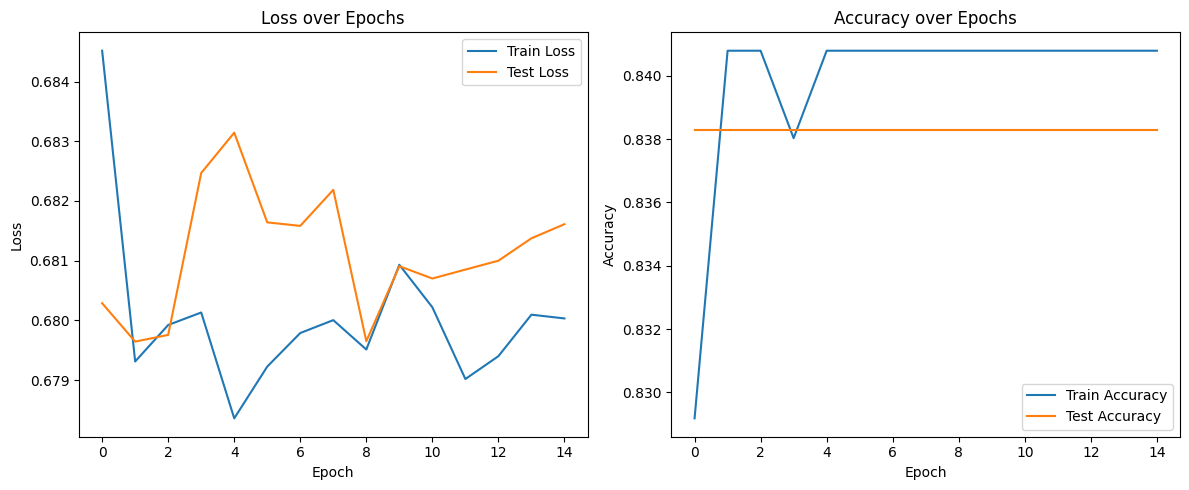

In [22]:
from ml_sandbox.train_eval import plot_training_history
plot_training_history(hist)

In [23]:
mlte.evaluate_torch_model(test_loader, model, device)

Confusion Matrix:
[[   0 1083]
 [   0 5614]]

Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1083
           1     0.8383    1.0000    0.9120      5614

    accuracy                         0.8383      6697
   macro avg     0.4191    0.5000    0.4560      6697
weighted avg     0.7027    0.8383    0.7645      6697



/home/stephen/miniforge3/envs/pytorch/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/stephen/miniforge3/envs/pytorch/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/stephen/miniforge3/envs/pytorch/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [29]:
from ml_sandbox.models import make_pca_rf_pipeline
model_skl = make_pca_rf_pipeline(n_pca_comp=150, n_trees=100, random_state=42)


In [ ]:
def test_convert_ds(dataset, batch_size=32, num_workers=None):
    """
    Convert a torch-style dataset to (X, y) using parallel workers.

    Uses a PyTorch `DataLoader` with `num_workers` to parallelize item loading
    and transforms. This avoids pickling the whole dataset object for
    multiprocessing and leverages DataLoader's worker pool.
    """
    import numpy as np
    from torch.utils.data import DataLoader
    import multiprocessing

    if num_workers is None:
        num_workers = min(4, multiprocessing.cpu_count())

    def collate_fn(batch):
        imgs = [b[0].cpu().numpy().ravel() for b in batch]
        labels = [int(b[1].item()) if hasattr(b[1], "item") else int(b[1]) for b in batch]
        return np.stack(imgs), np.array(labels, dtype=int)

    loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, collate_fn=collate_fn)

    X_parts = []
    y_parts = []
    for Xb, yb in loader:
        X_parts.append(Xb)
        y_parts.append(yb)

    if len(X_parts) == 0:
        return np.empty((0,)), np.empty((0,))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    return X, y


In [ ]:
# X_train, y_train = test_convert_ds(train_dataset)
# X_test, y_test = test_convert_ds(test_dataset)


In [ ]:
from ml_sandbox.dataset import convert_dataset_sklearn
X_train, y_train = convert_dataset_sklearn(train_dataset)
X_test, y_test = convert_dataset_sklearn(test_dataset)


In [ ]:
model_skl.fit(X_train, y_train)
test_accuracy = model_skl.score(X_test, y_test)
print(f'Test Accuracy: {test_accuracy:.4f}')
